# Statistics for TrueMeasures

This notebook compares exact and estimated statistics for three true measures:

- `Uniform`
- `Kumaraswamy`
- `Gaussian`

For each distribution, it estimates the mean, standard deviation, variance, and covariance using both `DigitalNetB2` and `IIDStdUniform`, then compares their replication-based convergence.


In [98]:
import numpy as np
import pandas as pd
import qmcpy as qp
import matplotlib.pyplot as plt
from IPython.display import display


def format_float(x):
    if x == 0:
        return "0.000"
    return f"{x:.3e}" if abs(x) < 5e-4 else f"{x:.3f}"


np.set_printoptions(formatter={"float_kind": format_float})
pd.set_option("display.float_format", format_float)


## 1. Configure the distribution examples

Each example is two dimensional. The `Uniform` distribution is defined on $[-2,4] \times [1,10]$, the `Kumaraswamy` distribution uses coordinate wise shape parameters, and the `Gaussian` example has correlated coordinates.


In [99]:
dimension = 2

example_specs = {
    "Uniform": {
        "constructor": qp.Uniform,
        "kwargs": {
            "lower_bound": np.array([-2.0, 1.0]),
            "upper_bound": np.array([4.0, 10.0]),
        },
    },
    "Kumaraswamy": {
        "constructor": qp.Kumaraswamy,
        "kwargs": {
            "a": np.array([1.0, 2.0]),
            "b": np.array([3.0, 4.0]),
        },
    },
    "Gaussian": {
        "constructor": qp.Gaussian,
        "kwargs": {
            "mean": np.array([1.0, 2.0]),
            "covariance": np.array([[9.0, 4.0], [4.0, 5.0]]),
        },
    },
}

sampler_classes = {
    "DigitalNetB2": qp.DigitalNetB2,
    "IIDStdUniform": qp.IIDStdUniform,
}

statistic_names = (
    "mean",
    "standard_deviation",
    "variance",
    "covariance",
)


def make_sampler(sampler_name, seed, replications=None):
    kwargs = {"dimension": dimension, "seed": seed}
    if replications is not None:
        kwargs["replications"] = replications
    return sampler_classes[sampler_name](**kwargs)


def make_true_measure(distribution_name, sampler):
    spec = example_specs[distribution_name]
    return spec["constructor"](sampler, **spec["kwargs"])


def calculate_statistics(samples):
    """Calculate statistics for samples shaped (..., n, dimension)."""
    sample_count = samples.shape[-2]
    mean = samples.mean(axis=-2)
    centered = samples - mean[..., None, :]
    covariance = np.einsum("...ni,...nj->...ij", centered, centered) / sample_count
    return {
        "mean": mean,
        "standard_deviation": samples.std(axis=-2, ddof=0),
        "variance": samples.var(axis=-2, ddof=0),
        "covariance": covariance,
    }


def statistic_label(statistic_name, index):
    coordinates = ",".join(map(str, index))
    return f"{statistic_name}[{coordinates}]"


exact_measures = {
    distribution_name: make_true_measure(
        distribution_name,
        make_sampler("DigitalNetB2", seed=7),
    )
    for distribution_name in example_specs
}

exact_statistics = {
    distribution_name: {
        statistic_name: np.asarray(getattr(measure, statistic_name))
        for statistic_name in statistic_names
    }
    for distribution_name, measure in exact_measures.items()
}


### Exact attributes

These are theoretical distribution statistics, not estimates from generated samples.


In [100]:
exact_rows = []

for distribution_name, statistics in exact_statistics.items():
    for statistic_name, values in statistics.items():
        for index in np.ndindex(values.shape):
            exact_rows.append(
                {
                    "Distribution": distribution_name,
                    "Statistic": statistic_label(statistic_name, index),
                    "True Value": float(values[index]),
                }
            )

exact_table = pd.DataFrame(exact_rows)

for distribution_name in example_specs:
    print(distribution_name)
    display(
        exact_table.loc[
            exact_table["Distribution"] == distribution_name,
            ["Statistic", "True Value"],
        ].reset_index(drop=True)
    )


Uniform


,Statistic,True Value
0,mean[0],1.000
1,mean[1],5.500
2,standard_deviation[0],1.732
3,standard_deviation[1],2.598
4,variance[0],3.000
5,variance[1],6.750
6,"covariance[0,0]",3.000
7,"covariance[0,1]",0.000
8,"covariance[1,0]",0.000
9,"covariance[1,1]",6.750


Kumaraswamy


,Statistic,True Value
0,mean[0],0.250
1,mean[1],0.406
2,standard_deviation[0],0.194
3,standard_deviation[1],0.187
4,variance[0],0.038
5,variance[1],0.035
6,"covariance[0,0]",0.038
7,"covariance[0,1]",0.000
8,"covariance[1,0]",0.000
9,"covariance[1,1]",0.035


Gaussian


,Statistic,True Value
0,mean[0],1.000
1,mean[1],2.000
2,standard_deviation[0],3.000
3,standard_deviation[1],2.236
4,variance[0],9.000
5,variance[1],5.000
6,"covariance[0,0]",9.000
7,"covariance[0,1]",4.000
8,"covariance[1,0]",4.000
9,"covariance[1,1]",5.000


## 2. Compare estimates from DigitalNetB2 and IIDStdUniform

Both samplers use $n=256$ for each distribution. The tables compare each estimate with its exact value.


In [101]:
n_demo = 2**8
demo_seed = 19
demo_samples = {}
demo_statistics = {}
comparison_tables = {}

for distribution_name in example_specs:
    demo_samples[distribution_name] = {}
    demo_statistics[distribution_name] = {}

    for sampler_name in sampler_classes:
        measure = make_true_measure(
            distribution_name,
            make_sampler(sampler_name, seed=demo_seed),
        )
        samples = measure(n_demo)
        demo_samples[distribution_name][sampler_name] = samples
        demo_statistics[distribution_name][sampler_name] = calculate_statistics(samples)

    rows = []
    for statistic_name in statistic_names:
        true_values = exact_statistics[distribution_name][statistic_name]
        for index in np.ndindex(true_values.shape):
            true_value = float(true_values[index])
            digital_estimate = float(
                demo_statistics[distribution_name]["DigitalNetB2"][statistic_name][index]
            )
            iid_estimate = float(
                demo_statistics[distribution_name]["IIDStdUniform"][statistic_name][index]
            )
            rows.append(
                {
                    "Statistic": statistic_label(statistic_name, index),
                    "True Value": true_value,
                    "DigitalNetB2 Estimate": digital_estimate,
                    "IID Estimate": iid_estimate,
                    "DigitalNetB2 Absolute Error": abs(digital_estimate - true_value),
                    "IID Absolute Error": abs(iid_estimate - true_value),
                }
            )

    comparison_tables[distribution_name] = pd.DataFrame(rows)

demo_comparison = pd.concat(comparison_tables, names=["Distribution", "Row"])

for distribution_name, table in comparison_tables.items():
    print(f"{distribution_name}, n={n_demo}")
    display(table)


Uniform, n=256


,Statistic,True Value,DigitalNetB2 Estimate,IID Estimate,DigitalNetB2 Absolute Error,IID Absolute Error
0,mean[0],1.000,1.000,0.889,0.000,0.111
1,mean[1],5.500,5.500,5.452,2.665e-15,0.048
2,standard_deviation[0],1.732,1.732,1.733,3.270e-04,0.001
3,standard_deviation[1],2.598,2.598,2.583,2.904e-08,0.015
4,variance[0],3.000,3.001,3.005,0.001,0.005
5,variance[1],6.750,6.750,6.670,1.509e-07,0.080
6,"covariance[0,0]",3.000,3.001,3.005,0.001,0.005
7,"covariance[0,1]",0.000,4.989e-05,0.215,4.989e-05,0.215
8,"covariance[1,0]",0.000,4.989e-05,0.215,4.989e-05,0.215
9,"covariance[1,1]",6.750,6.750,6.670,1.509e-07,0.080


Kumaraswamy, n=256


,Statistic,True Value,DigitalNetB2 Estimate,IID Estimate,DigitalNetB2 Absolute Error,IID Absolute Error
0,mean[0],0.250,0.250,0.238,2.017e-04,0.012
1,mean[1],0.406,0.406,0.401,2.315e-05,0.005
2,standard_deviation[0],0.194,0.194,0.190,0.001,0.003
3,standard_deviation[1],0.187,0.187,0.182,1.371e-05,0.005
4,variance[0],0.038,0.038,0.036,2.559e-04,0.001
5,variance[1],0.035,0.035,0.033,5.119e-06,0.002
6,"covariance[0,0]",0.038,0.038,0.036,2.559e-04,0.001
7,"covariance[0,1]",0.000,-4.246e-05,0.003,4.246e-05,0.003
8,"covariance[1,0]",0.000,-4.246e-05,0.003,4.246e-05,0.003
9,"covariance[1,1]",0.035,0.035,0.033,5.119e-06,0.002


Gaussian, n=256


,Statistic,True Value,DigitalNetB2 Estimate,IID Estimate,DigitalNetB2 Absolute Error,IID Absolute Error
0,mean[0],1.000,1.005,0.780,0.005,0.220
1,mean[1],2.000,2.003,1.922,0.003,0.078
2,standard_deviation[0],3.000,3.012,3.074,0.012,0.074
3,standard_deviation[1],2.236,2.241,2.166,0.005,0.070
4,variance[0],9.000,9.072,9.447,0.072,0.447
5,variance[1],5.000,5.024,4.692,0.024,0.308
6,"covariance[0,0]",9.000,9.072,9.447,0.072,0.447
7,"covariance[0,1]",4.000,4.052,4.042,0.052,0.042
8,"covariance[1,0]",4.000,4.052,4.042,0.052,0.042
9,"covariance[1,1]",5.000,5.024,4.692,0.024,0.308


## 3. Visualize point coverage

The rows show the three target distributions; the columns compare low-discrepancy and IID sampling at the same sample size.


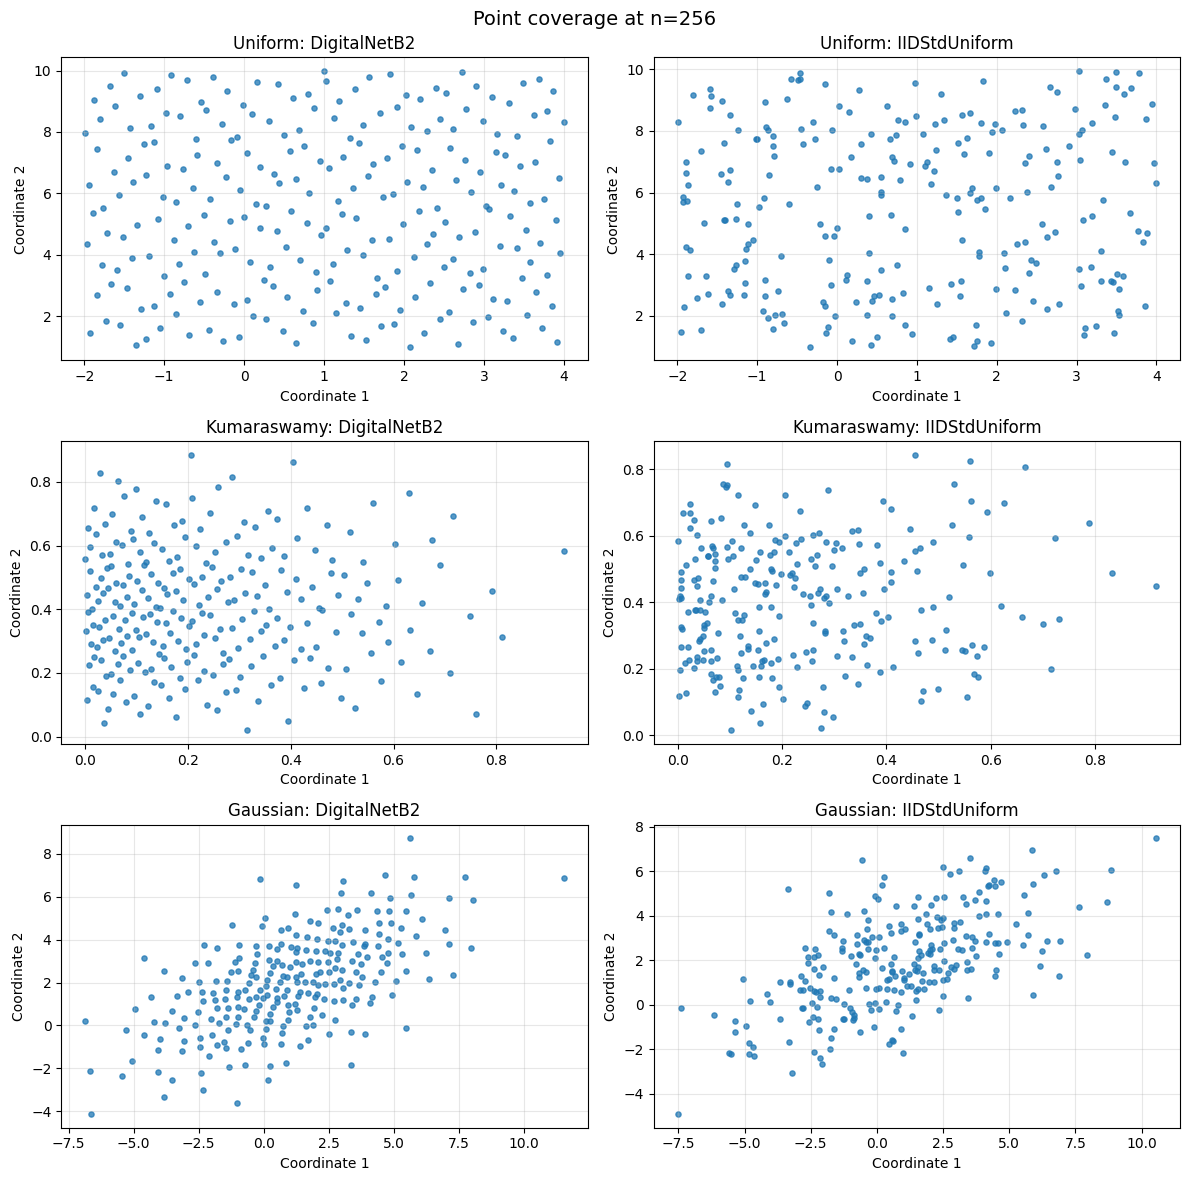

In [102]:
fig, axes = plt.subplots(
    len(example_specs),
    len(sampler_classes),
    figsize=(12, 12),
)

for row, distribution_name in enumerate(example_specs):
    for column, sampler_name in enumerate(sampler_classes):
        samples = demo_samples[distribution_name][sampler_name]
        ax = axes[row, column]
        ax.scatter(samples[:, 0], samples[:, 1], s=14, alpha=0.75)
        ax.set_title(f"{distribution_name}: {sampler_name}")
        ax.set_xlabel("Coordinate 1")
        ax.set_ylabel("Coordinate 2")
        ax.grid(True, alpha=0.3)

fig.suptitle(f"Point coverage at n={n_demo}", fontsize=14)
fig.tight_layout()
plt.show()


## 4. Replication based convergence experiment

For each distribution and sample size, this experiment computes RMSE over 8 independent replications for both samplers. Each RMSE aggregates the errors over the replications and all entries of the corresponding statistic.


In [103]:
sample_sizes = 2 ** np.arange(4, 11)
replications = 8
base_seed = 2026
records = []

for distribution_name in example_specs:
    targets = exact_statistics[distribution_name]

    for n in sample_sizes:
        for sampler_name in sampler_classes:
            measure = make_true_measure(
                distribution_name,
                make_sampler(
                    sampler_name,
                    seed=base_seed,
                    replications=replications,
                ),
            )
            estimates = calculate_statistics(measure(int(n)))

            for statistic_name in statistic_names:
                rmse = np.sqrt(
                    np.mean((estimates[statistic_name] - targets[statistic_name]) ** 2)
                )
                records.append(
                    {
                        "distribution": distribution_name,
                        "sampler": sampler_name,
                        "n": int(n),
                        "statistic": statistic_name,
                        "rmse": rmse,
                    }
                )

results = pd.DataFrame(records)

summary = (
    results.pivot(
        index=["distribution", "sampler", "n"],
        columns="statistic",
        values="rmse",
    )
    .reset_index()
    .rename(
        columns={
            "distribution": "Distribution",
            "sampler": "Sampler",
            "covariance": "Covariance",
            "mean": "Mean",
            "standard_deviation": "Standard Deviation",
            "variance": "Variance",
        }
    )
)
summary.columns.name = None
summary = summary[
    [
        "Distribution",
        "Sampler",
        "n",
        "Mean",
        "Standard Deviation",
        "Variance",
        "Covariance",
    ]
]

convergence_tables = {
    distribution_name: summary[
        summary["Distribution"] == distribution_name
    ].drop(columns="Distribution").reset_index(drop=True)
    for distribution_name in example_specs
}

for distribution_name, table in convergence_tables.items():
    print(f"{distribution_name} RMSE")
    display(table)


Uniform RMSE


,Sampler,n,Mean,Standard Deviation,Variance,Covariance
0,DigitalNetB2,16,0.049,0.027,0.123,0.152
1,DigitalNetB2,32,0.018,0.004,0.021,0.082
2,DigitalNetB2,64,0.002,0.001,0.005,0.015
3,DigitalNetB2,128,5.722e-06,0.001,0.003,0.013
4,DigitalNetB2,256,1.597e-15,4.757e-04,0.002,0.002
5,DigitalNetB2,512,2.844e-15,1.271e-05,4.531e-05,0.001
6,DigitalNetB2,1024,1.958e-15,3.734e-06,1.678e-05,3.846e-05
7,IIDStdUniform,16,0.513,0.212,0.995,1.028
8,IIDStdUniform,32,0.267,0.148,0.694,0.757
9,IIDStdUniform,64,0.261,0.133,0.658,0.702


Kumaraswamy RMSE


,Sampler,n,Mean,Standard Deviation,Variance,Covariance
0,DigitalNetB2,16,0.007,0.013,0.005,0.004
1,DigitalNetB2,32,0.002,0.005,0.002,0.002
2,DigitalNetB2,64,0.001,0.002,0.001,0.001
3,DigitalNetB2,128,2.762e-04,0.001,3.028e-04,2.936e-04
4,DigitalNetB2,256,9.523e-05,3.219e-04,1.219e-04,1.052e-04
5,DigitalNetB2,512,5.272e-05,1.685e-04,6.497e-05,5.270e-05
6,DigitalNetB2,1024,1.574e-05,5.577e-05,2.143e-05,1.911e-05
7,IIDStdUniform,16,0.041,0.026,0.010,0.009
8,IIDStdUniform,32,0.025,0.019,0.007,0.007
9,IIDStdUniform,64,0.026,0.021,0.008,0.007


Gaussian RMSE


,Sampler,n,Mean,Standard Deviation,Variance,Covariance
0,DigitalNetB2,16,0.125,0.190,1.033,1.012
1,DigitalNetB2,32,0.041,0.115,0.654,0.633
2,DigitalNetB2,64,0.014,0.056,0.321,0.289
3,DigitalNetB2,128,0.007,0.025,0.143,0.118
4,DigitalNetB2,256,0.004,0.012,0.063,0.058
5,DigitalNetB2,512,0.003,0.005,0.025,0.022
6,DigitalNetB2,1024,0.001,0.003,0.014,0.013
7,IIDStdUniform,16,0.584,0.310,1.584,1.311
8,IIDStdUniform,32,0.374,0.195,0.910,1.025
9,IIDStdUniform,64,0.426,0.215,1.156,1.168


## 5. Convergence plots

Lower RMSE means that an estimate is closer to the exact statistic. Steeper downward curves indicate faster observed convergence.


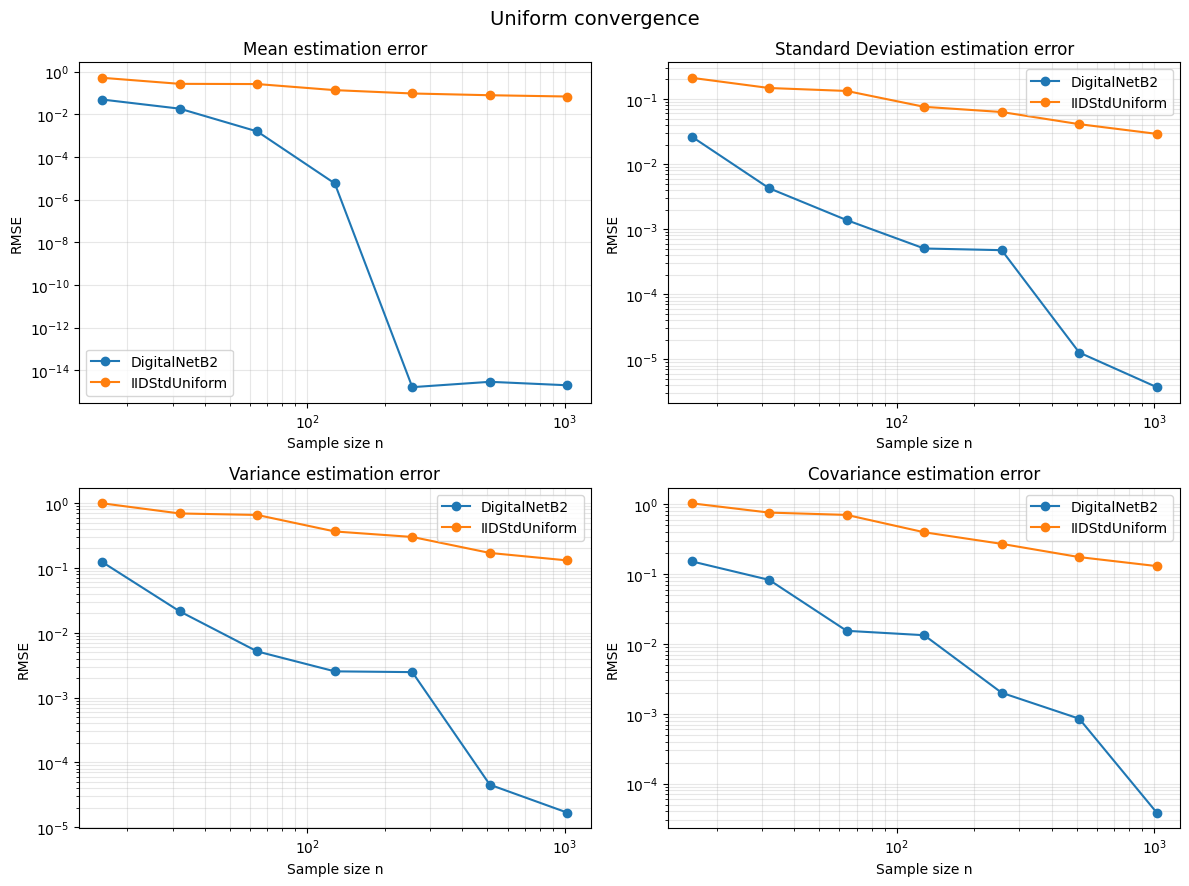

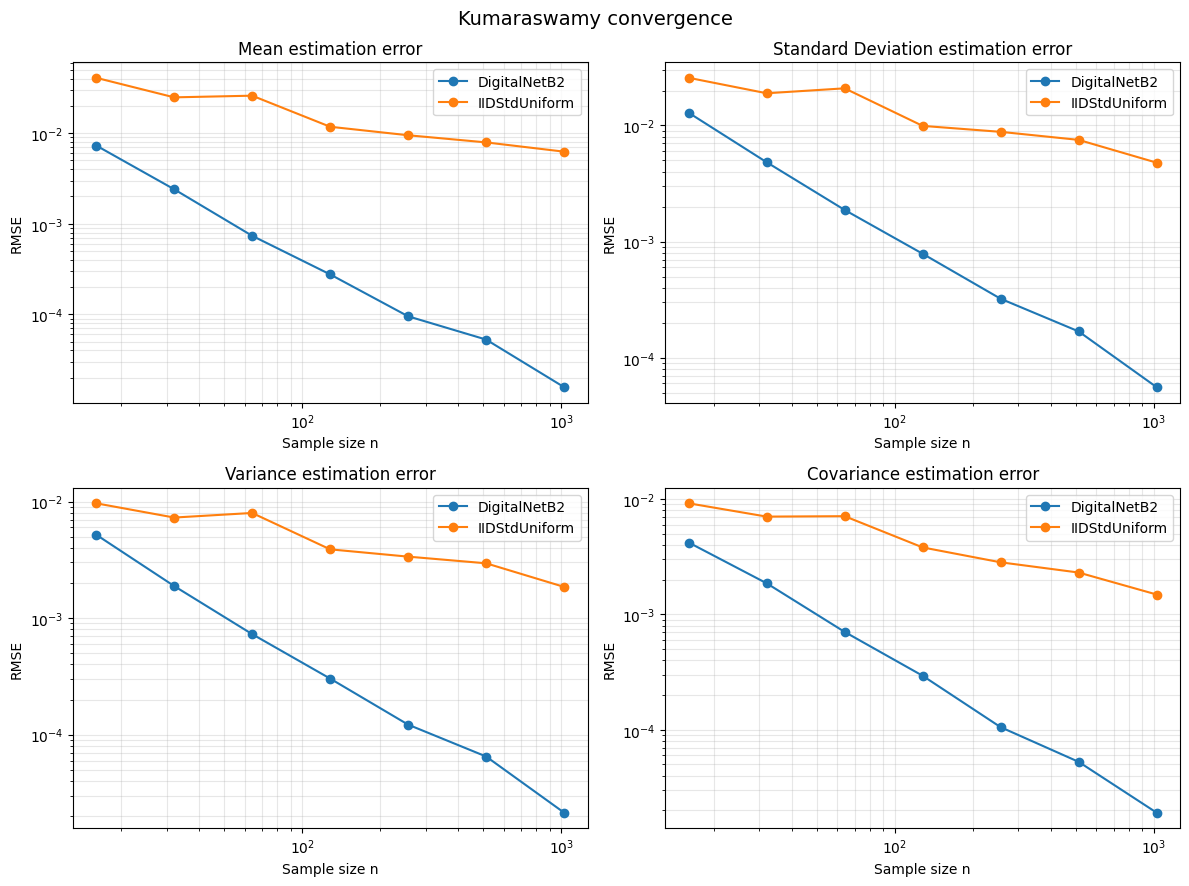

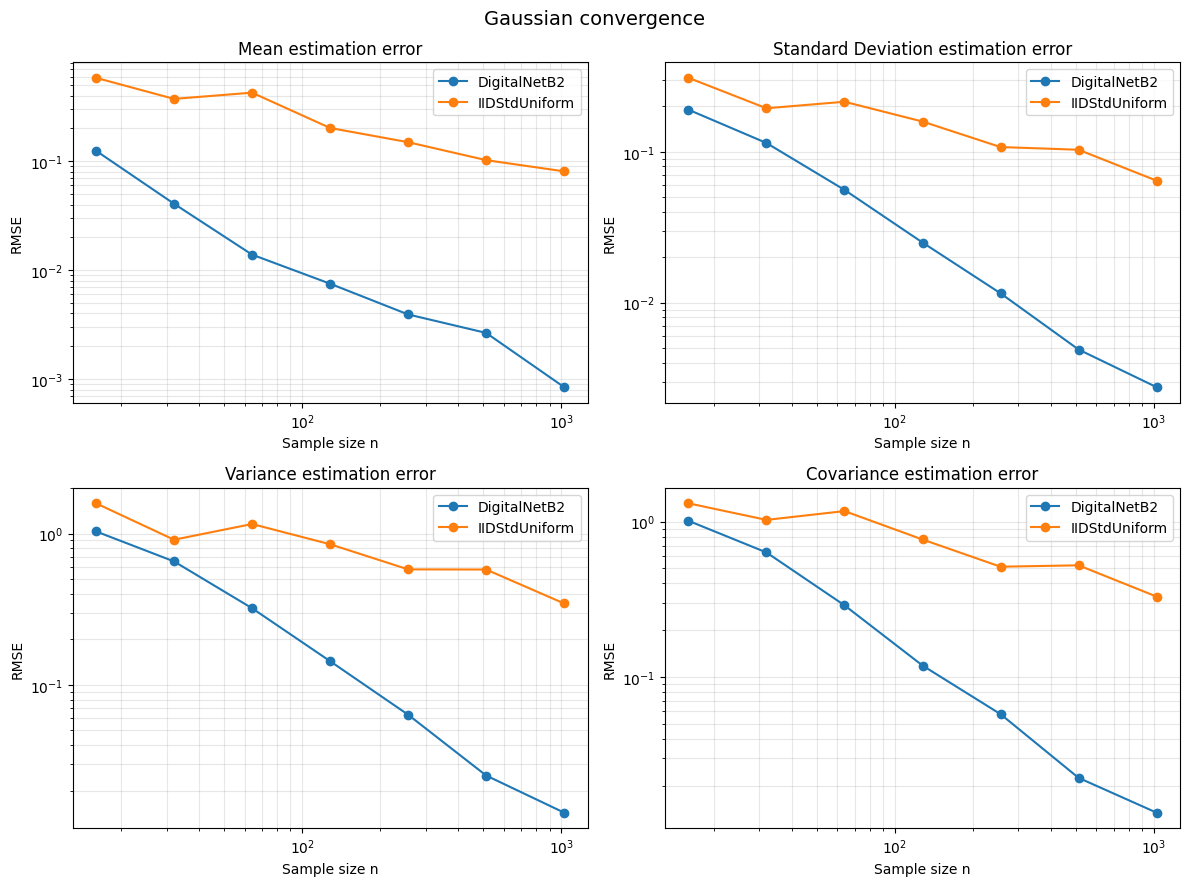

In [104]:
statistic_titles = {
    "mean": "Mean",
    "standard_deviation": "Standard Deviation",
    "variance": "Variance",
    "covariance": "Covariance",
}

for distribution_name in example_specs:
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    for ax, statistic_name in zip(axes.flat, statistic_names):
        plot_data = results[
            (results["distribution"] == distribution_name)
            & (results["statistic"] == statistic_name)
        ]

        for sampler_name in sampler_classes:
            sampler_data = plot_data[
                plot_data["sampler"] == sampler_name
            ].sort_values("n")
            ax.loglog(
                sampler_data["n"],
                sampler_data["rmse"],
                marker="o",
                label=sampler_name,
            )

        ax.set_title(f"{statistic_titles[statistic_name]} estimation error")
        ax.set_xlabel("Sample size n")
        ax.set_ylabel("RMSE")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

    fig.suptitle(f"{distribution_name} convergence", fontsize=14)
    fig.tight_layout()
    plt.show()


## Interpretation

DigitalNetB2 shows a lower replication averaged error and a much faster decrease in error than IIDStdUniform for Uniform, Kumaraswamy, and Gaussian.